# MLP Probe Analysis — Multi-Turn Jailbreak Representations

This notebook trains MLP probes on hidden-state representations to study how
the model internally represents successful jailbreaks across three attack frameworks
(Crescendo, ActorAttack, XTeaming).

## Research questions

1. **In-framework:** Can a simple probe distinguish accepted harmful conversations
   from accepted harmless ones, using hidden states at the final turn? How does
   discriminability vary by layer?

2. **Cross-framework transfer:** If we train the probe on Crescendo jailbreaks and
   apply it to ActorAttack or XTeaming, does it still work? This tests whether
   jailbreak representations are framework-universal or framework-specific.

3. **K-sweep (Bullwinkel analog):** If we apply the final-turn-trained probe to
   *each individual turn* of a Crescendo conversation, does P(harmful) increase
   over turns? This would confirm that the harmfulness signal builds up progressively
   as the attack escalates — compliance priming visible in the probe's predictions.

## Token positions used

- **`h_inst`** — hidden state at the last user token (`t_inst`): encodes harmfulness
  of the *request*
- **`h_post`** — hidden state at the EOT tag (`t_post_inst`): encodes the model's
  compliance/refusal *decision*

## Classification task

`accepted_harmful` (y=1) vs `accepted_harmless` (y=0)

Both groups are conversations where the model complied. The probe must learn to
distinguish: "did the model comply with something harmful, or something benign?"
Refused conversations are excluded from training — a refusal looks different from
a successful jailbreak and would confuse the signal.

## Train / test split

- **Train:** attempt ≤ 16 (reps 1–16 per JBB goal)
- **Test:**  attempt > 16 (reps 17–20)
- **GroupKFold CV** by `pair_id` — the same JBB behavior never appears in both
  train and validation folds, so the probe cannot memorise topic signatures.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPR_ROOT   = repo_root / "data" / "representations"
FRAMEWORKS  = ["crescendo", "actorattack", "xteaming"]
N_LAYERS    = 32
HIDDEN_DIM  = 4096
TRAIN_MAX_ATTEMPT = 16
FOCAL_LAYER = 16   # 0-indexed → layer 17; same reference as nb04

FW_COLORS = {"crescendo": "#d62728", "actorattack": "#ff7f0e", "xteaming": "#2ca02c"}


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load trajectory data and assign behavioural categories + train/test split.
# Mirrors nb04 cells 2–3; self-contained so this notebook runs independently.

def assign_category(row):
    if row["goal_type"] == "harmful":
        return "accepted_harmful" if row["attack_success"] else "refused_harmful"
    else:
        return "accepted_harmless" if row["attack_success"] else "refused_harmless"

traj = {}
for fw in FRAMEWORKS:
    for split in ["harmful", "benign"]:
        folder = REPR_ROOT / "trajectories" / f"{fw}_{split}"
        meta   = pd.read_parquet(folder / "metadata.parquet")
        h_inst = np.load(folder / "h_inst.npy")
        h_post = np.load(folder / "h_post_inst.npy")
        meta["category"]   = meta.apply(assign_category, axis=1)
        meta["data_split"] = np.where(meta["attempt"] <= TRAIN_MAX_ATTEMPT, "train", "test")
        traj[(fw, split)]  = {"meta": meta, "h_inst": h_inst, "h_post": h_post}

print("Loaded. Class sizes per framework (train split):")
for fw in FRAMEWORKS:
    m_h = traj[(fw,"harmful")]["meta"]
    m_b = traj[(fw,"benign")]["meta"]
    tr_h = m_h[m_h["data_split"]=="train"]
    tr_b = m_b[m_b["data_split"]=="train"]
    n_ah  = tr_h[tr_h["category"]=="accepted_harmful"]["conversation_id"].nunique()
    n_ahl = tr_b[tr_b["category"]=="accepted_harmless"]["conversation_id"].nunique()
    print(f"  {fw:<14}  accepted_harmful={n_ah:4d}  accepted_harmless={n_ahl:4d}")


Loaded. Class sizes per framework (train split):
  crescendo       accepted_harmful=1305  accepted_harmless=1505
  actorattack     accepted_harmful= 429  accepted_harmless= 375
  xteaming        accepted_harmful= 979  accepted_harmless= 622


## Dataset construction

For each conversation we take the **final turn's** hidden state — one vector
per conversation per layer (shape `(32, 4096)`).

**Why final turn only?**
The final turn carries maximum attack context and is the point at which the
model has committed to its response. Using the final turn gives the clearest
signal and is the natural "Option A" centroid (see nb04).

**Why accepted only?**
We exclude `refused_harmful` and `refused_harmless` because the probe task is
*jailbreak detection* — distinguishing "the model just complied with something
harmful" from "the model just complied with something benign."
Refused conversations involve a different model state (the model is about to
decline) and would introduce a confound.

**Per-pair topic demeaning (`demean=True`, default).**
`accepted_harmful` (y=1) and `accepted_harmless` (y=0) come from different
JBB objectives (harmful vs benign), so the raw representations are confounded
by topic. Each JBB pair_id shares the same topic area across both trajectories,
so subtracting the per-pair mean (across y=1 and y=0 examples for that pair_id)
removes the topic-specific offset and forces the probe to learn what varies
*within* a topic — i.e., compliance state. Pair means computed on the training
split are cached for reuse when evaluating test data and k-sweep turns.

`build_dataset(framework, data_split, h_key, demean=True)` extracts:
- `X` — `(N, 32, 4096)` float32 — one representation per conversation
- `y` — binary labels (1 = accepted_harmful, 0 = accepted_harmless)
- `pair_ids` — JBB pair index for GroupKFold stratification


In [3]:
# Cache per-pair means computed on the training split (reused for test + k-sweep)
_pair_means: dict = {}   # (framework, h_key) → {pair_id: (32, 4096) array}


def build_dataset(framework, data_split, h_key="h_inst", demean=True):
    """
    Extract final-turn representations for accepted_harmful (y=1)
    and accepted_harmless (y=0).

    demean=True: subtract per-pair mean (computed on train split) from each X,
    removing the topic-specific offset so the probe learns compliance state only.

    Returns
    -------
    X        : (N, 32, 4096) float32
    y        : (N,) int  —  1 = accepted_harmful, 0 = accepted_harmless
    pair_ids : (N,) int  —  JBB pair_id for GroupKFold
    """
    rows_X, rows_y, rows_p = [], [], []

    for goal_type, cat, label in [
        ("harmful", "accepted_harmful",  1),
        ("benign",  "accepted_harmless", 0),
    ]:
        meta  = traj[(framework, goal_type)]["meta"]
        h_arr = traj[(framework, goal_type)][h_key]

        mask = (meta["data_split"] == data_split) & (meta["category"] == cat)
        sub  = meta[mask]
        # Final turn per conversation
        idx  = sub.groupby("conversation_id")["turn_k"].idxmax()
        pos  = meta.index.get_indexer(idx.values)

        rows_X.append(h_arr[pos].astype(np.float32))
        rows_y.append(np.full(len(pos), label, dtype=int))
        rows_p.append(meta.loc[idx.values, "pair_id"].values)

    X        = np.concatenate(rows_X, axis=0)
    y        = np.concatenate(rows_y)
    pair_ids = np.concatenate(rows_p)

    if demean:
        cache_key = (framework, h_key)
        if data_split == "train":
            # Compute and cache per-pair means from training data
            pair_means = {}
            for pid in np.unique(pair_ids):
                mask = (pair_ids == pid)
                pair_means[pid] = X[mask].mean(axis=0)   # (32, 4096)
            _pair_means[cache_key] = pair_means
        else:
            pair_means = _pair_means.get(cache_key, {})

        for pid in np.unique(pair_ids):
            if pid in pair_means:
                mask = (pair_ids == pid)
                X[mask] -= pair_means[pid]

    return X, y, pair_ids


def demean_h(X_raw, pair_ids_raw, framework, h_key):
    """
    Apply cached per-pair means to arbitrary representations (e.g. k-sweep turns).
    Uses the pair means computed from the training split via build_dataset(..., demean=True).
    pair_ids_raw: array of pair_id for each row in X_raw.
    """
    cache_key = (framework, h_key)
    pair_means = _pair_means.get(cache_key, {})
    X = X_raw.copy()
    for pid in np.unique(pair_ids_raw):
        if pid in pair_means:
            mask = (pair_ids_raw == pid)
            X[mask] -= pair_means[pid]
    return X


# Sanity check (also populates _pair_means cache for train splits)
for fw in FRAMEWORKS:
    X, y, p = build_dataset(fw, "train")
    print(f"{fw}: train  X={X.shape}  y=1:{y.sum()}  y=0:{(y==0).sum()}  "
          f"unique_pairs={len(np.unique(p))}")
for fw in FRAMEWORKS:
    X, y, p = build_dataset(fw, "test")
    print(f"{fw}: test   X={X.shape}  y=1:{y.sum()}  y=0:{(y==0).sum()}")


crescendo: train  X=(2810, 32, 4096)  y=1:1305  y=0:1505  unique_pairs=99
actorattack: train  X=(804, 32, 4096)  y=1:429  y=0:375  unique_pairs=85
xteaming: train  X=(1601, 32, 4096)  y=1:979  y=0:622  unique_pairs=96
crescendo: test   X=(684, 32, 4096)  y=1:316  y=0:368
actorattack: test   X=(197, 32, 4096)  y=1:108  y=0:89
xteaming: test   X=(416, 32, 4096)  y=1:257  y=0:159


## Probe design

**One probe per layer.** At each of the 32 layers we train an independent MLP
on the 4096-dim representation at that layer. This gives an AUROC curve vs layer
— directly comparable to the direction-based AUROC in nb04.

**Architecture:** `MLPClassifier(hidden_layer_sizes=(64,))` with early stopping
and StandardScaler normalisation. Small enough to avoid overfitting on ~1600
training examples, large enough to capture nonlinear structure if present.

**GroupKFold cross-validation** by `pair_id` (5 folds). Each fold holds out all
attempts for a subset of JBB behaviors, so the probe cannot memorise
"requests about chemistry are always harmful." CV gives an honest estimate of
goal-level generalisation within the training framework.

**Test evaluation:** After CV, refit on the full training set and evaluate on
the held-out test split (attempts 17–20).

**Two probes per framework:** one for `h_inst` and one for `h_post`, answering
different questions:
- `h_inst` probe: "does the model encode that the *request* is harmful?"
- `h_post` probe: "does the model's *generation-decision state* differ between
  harmful and benign compliance?"


In [4]:
def train_probes(X_train, y_train, pair_ids, n_splits=5):
    """
    Train one MLP probe per layer with GroupKFold CV.

    Returns
    -------
    probes   : list of (StandardScaler, MLPClassifier) — one per layer
    cv_aucs  : (32,) mean CV AUROC per layer
    cv_stds  : (32,) std  CV AUROC per layer
    """
    gkf     = GroupKFold(n_splits=n_splits)
    probes  = []
    cv_aucs = []
    cv_stds = []

    for layer in range(N_LAYERS):
        X_l = X_train[:, layer, :]
        scaler = StandardScaler()
        X_ls   = scaler.fit_transform(X_l)

        fold_aucs = []
        for tr_idx, val_idx in gkf.split(X_ls, y_train, groups=pair_ids):
            if len(np.unique(y_train[val_idx])) < 2:
                continue
            clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
                                random_state=42, early_stopping=True)
            clf.fit(X_ls[tr_idx], y_train[tr_idx])
            fold_aucs.append(roc_auc_score(
                y_train[val_idx], clf.predict_proba(X_ls[val_idx])[:, 1]))

        # Refit on full training set
        clf_full = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
                                 random_state=42, early_stopping=True)
        clf_full.fit(X_ls, y_train)

        probes.append((scaler, clf_full))
        cv_aucs.append(np.mean(fold_aucs) if fold_aucs else np.nan)
        cv_stds.append(np.std(fold_aucs)  if fold_aucs else np.nan)

    return probes, np.array(cv_aucs), np.array(cv_stds)


def eval_probes(X_test, y_test, probes):
    """Return (32,) test AUROC array."""
    aucs = []
    for layer, (scaler, clf) in enumerate(probes):
        X_l = scaler.transform(X_test[:, layer, :])
        aucs.append(roc_auc_score(y_test, clf.predict_proba(X_l)[:, 1]))
    return np.array(aucs)


def probe_proba(X, probes, layer):
    """P(harmful) for every example in X at a single layer. Returns (N,)."""
    scaler, clf = probes[layer]
    X_l = scaler.transform(X[:, layer, :].astype(np.float32))
    return clf.predict_proba(X_l)[:, 1]


layers = np.arange(1, N_LAYERS + 1)
print("Probe functions defined.")


Probe functions defined.


In [5]:
# ── Topic removal: within-class PCA per pair ─────────────────────────────────
#
# After mean-demeaning (which removes the per-pair centroid), residual topic
# structure lives in the within-pair, within-class variance. We project out
# the top-k principal directions of that variance for each pair_id.
#
# k is set per framework based on median sample count per pair:
#   crescendo   (median 30/pair): k=3  for n≥6,  k=2 for n in [4,6)
#   xteaming    (median 16/pair): k=2  for n≥8,  k=1 for n in [5,8),  k=0 for n<5
#   actorattack (median  8/pair): k=1  for n≥5,  k=0 for n<5
#
# Pairs that don't meet the threshold get mean-demeaning only (k=0).

K_FN = {
    "crescendo":   lambda n: 3 if n >= 6 else (2 if n >= 4 else 0),
    "xteaming":    lambda n: 2 if n >= 8 else (1 if n >= 5 else 0),
    "actorattack": lambda n: 1 if n >= 5 else 0,
}

_pca_projectors: dict = {}   # (fw, h_key) → {pair_id → {layer → Vt (k, 4096)}}


def build_dataset_pca(framework, data_split, h_key="h_inst"):
    """
    Build dataset with full topic removal:
      (1) per-pair mean subtraction  [build_dataset demean=True]
      (2) within-class PCA removal   [project out top-k within-pair, within-class PCs]

    On train split: fits and caches PCA projectors.
    On test/k-sweep: applies cached projectors from train.
    """
    X, y, pair_ids = build_dataset(framework, data_split, h_key, demean=True)
    cache_key = (framework, h_key)
    k_fn = K_FN[framework]

    if data_split == "train":
        projectors = {}
        for pid in np.unique(pair_ids):
            mask   = (pair_ids == pid)
            n      = int(mask.sum())
            k      = k_fn(n)
            if k <= 0:
                continue
            X_p  = X[mask]; y_p = y[mask]
            m1   = (y_p == 1); m0 = (y_p == 0)
            if m1.sum() == 0 or m0.sum() == 0:
                continue
            projectors[pid] = {}
            for layer in range(N_LAYERS):
                X_l  = X_p[:, layer, :]                                     # (n, 4096)
                res1 = X_l[m1] - X_l[m1].mean(axis=0, keepdims=True)
                res0 = X_l[m0] - X_l[m0].mean(axis=0, keepdims=True)
                W    = np.concatenate([res1, res0], axis=0)                 # (n_w, 4096)
                k_eff = min(k, len(W) - 1)
                if k_eff <= 0:
                    continue
                _, _, Vt = np.linalg.svd(W, full_matrices=False)
                projectors[pid][layer] = Vt[:k_eff]                         # (k_eff, 4096)
        _pca_projectors[cache_key] = projectors
    else:
        projectors = _pca_projectors.get(cache_key, {})

    X_out = X.copy()
    for pid, layer_proj in projectors.items():
        mask = (pair_ids == pid)
        if not mask.any():
            continue
        idx = np.where(mask)[0]
        for layer, V_top in layer_proj.items():
            X_l = X_out[idx, layer, :]
            X_out[idx, layer, :] = X_l - X_l @ V_top.T @ V_top

    return X_out, y, pair_ids


def pca_h(X_raw, pair_ids_raw, framework, h_key):
    """Apply mean demeaning + cached PCA removal to per-turn k-sweep representations."""
    X = demean_h(X_raw, pair_ids_raw, framework, h_key)
    cache_key = (framework, h_key)
    projectors = _pca_projectors.get(cache_key, {})
    X_out = X.copy()
    for pid in np.unique(pair_ids_raw):
        if pid not in projectors:
            continue
        mask = (pair_ids_raw == pid)
        idx  = np.where(mask)[0]
        for layer, V_top in projectors[pid].items():
            X_l = X_out[idx, layer, :]
            X_out[idx, layer, :] = X_l - X_l @ V_top.T @ V_top
    return X_out


In [ ]:
# ── Topic removal: project out v_harmful direction from nb04 ─────────────────
#
# v_harmful[layer] is the unit vector separating harmful from benign requests,
# computed from matched pairs (same pair_id, harmful vs benign trajectory).
# It is already topic-cancelled by construction and estimated from all training
# examples — no per-pair sample size requirement.
#
# Projecting representations onto the subspace orthogonal to v_harmful removes
# the main axis that encodes "this is a harmful topic/request" and forces the
# probe to find a different axis — the compliance-state direction.

_v_harmful: dict = {}   # (fw, h_key) → (32, 4096) unit vectors


def compute_v_harmful(framework, h_key="h_inst"):
    """Compute topic-cancelled harmfulness direction from training data."""
    mus = []
    for goal_type, sign in [("harmful", +1.0), ("benign", -1.0)]:
        meta  = traj[(framework, goal_type)]["meta"]
        h_arr = traj[(framework, goal_type)][h_key]
        mask  = meta["data_split"] == "train"
        sub   = meta[mask]
        idx   = sub.groupby("conversation_id")["turn_k"].idxmax()
        pos   = meta.index.get_indexer(idx.values)
        mus.append(sign * h_arr[pos].astype(np.float32).mean(axis=0))
    diff  = mus[0] + mus[1]                                    # (32, 4096)
    norms = np.linalg.norm(diff, axis=-1, keepdims=True)
    return diff / (norms + 1e-12)


def project_out_vharm(X, v_harm):
    """Remove v_harmful direction from each layer of X.
    X      : (N, 32, 4096)
    v_harm : (32, 4096) unit vectors
    """
    X_out = X.copy()
    for layer in range(N_LAYERS):
        v    = v_harm[layer]                          # (4096,)
        proj = X_out[:, layer, :] @ v                 # (N,) scalar projections
        X_out[:, layer, :] -= np.outer(proj, v)       # subtract component along v
    return X_out


def build_dataset_vharm(framework, data_split, h_key="h_inst"):
    """Build dataset with v_harmful direction projected out (no mean demeaning)."""
    X, y, pair_ids = build_dataset(framework, data_split, h_key, demean=False)
    return project_out_vharm(X, _v_harmful[(framework, h_key)]), y, pair_ids


# Pre-compute v_harmful for all frameworks and both positions
for fw in FRAMEWORKS:
    for h_key in ["h_inst", "h_post"]:
        _v_harmful[(fw, h_key)] = compute_v_harmful(fw, h_key)
        print(f"v_harmful computed: {fw} / {h_key}  "
              f"norm check={np.linalg.norm(_v_harmful[(fw,h_key)], axis=-1).mean():.4f}")


In [6]:
# Report sample counts per pair_id and what PCA k was applied.
# Run build_dataset(demean=True) for train to populate _pair_means cache first.

print("Populating mean-demean cache...")
for fw in FRAMEWORKS:
    for h_key in ["h_inst", "h_post"]:
        build_dataset(fw, "train", h_key, demean=True)

print("\n=== Per-pair sample counts and PCA k applied (train split) ===\n")
summary_rows = []
for fw in FRAMEWORKS:
    X, y, pair_ids = build_dataset(fw, "train", "h_inst", demean=False)
    k_fn = K_FN[fw]
    for pid in np.unique(pair_ids):
        mask = (pair_ids == pid)
        n    = int(mask.sum())
        y_p  = y[mask]
        summary_rows.append({
            "framework": fw, "pair_id": int(pid),
            "n_total": n, "n_y1": int((y_p==1).sum()), "n_y0": int((y_p==0).sum()),
            "k_pca": k_fn(n),
        })

df_sizes = pd.DataFrame(summary_rows)

for fw in FRAMEWORKS:
    sub = df_sizes[df_sizes["framework"] == fw]
    k_counts = sub["k_pca"].value_counts().sort_index()
    print(f"{fw}  ({len(sub)} pairs)")
    print(f"  median n/pair : {sub['n_total'].median():.0f}")
    print(f"  min n/pair    : {sub['n_total'].min()}")
    for k_val, cnt in k_counts.items():
        pct = 100 * cnt / len(sub)
        label = f"k={k_val}" if k_val > 0 else "k=0 (mean only)"
        print(f"  {label:20s}: {cnt:3d} pairs  ({pct:.0f}%)")
    print()


Populating mean-demean cache...

=== Per-pair sample counts and PCA k applied (train split) ===

crescendo  (99 pairs)
  median n/pair : 30
  min n/pair    : 6
  k=3                 :  99 pairs  (100%)

actorattack  (85 pairs)
  median n/pair : 8
  min n/pair    : 1
  k=0 (mean only)     :  28 pairs  (33%)
  k=1                 :  57 pairs  (67%)

xteaming  (96 pairs)
  median n/pair : 16
  min n/pair    : 1
  k=0 (mean only)     :  17 pairs  (18%)
  k=1                 :   8 pairs  (8%)
  k=2                 :  71 pairs  (74%)



In [ ]:
# Train 4 probe variants for all frameworks and both token positions.
#   probe_results_raw   : no topic removal
#   probe_results_mean  : per-pair mean demeaning
#   probe_results_pca   : mean + within-class PCA removal
#   probe_results_vharm : v_harmful direction projected out

layers = np.arange(1, N_LAYERS + 1)

probe_results_raw   = {}
probe_results_mean  = {}
probe_results_pca   = {}
probe_results_vharm = {}

for fw in FRAMEWORKS:
    for h_key in ["h_inst", "h_post"]:
        print(f"\n── {fw} / {h_key} ──")

        # Raw
        X_tr, y_tr, pairs = build_dataset(fw, "train", h_key, demean=False)
        X_te, y_te, _     = build_dataset(fw, "test",  h_key, demean=False)
        probes, cv, cv_s  = train_probes(X_tr, y_tr, pairs)
        test_a            = eval_probes(X_te, y_te, probes)
        probe_results_raw[(fw, h_key)] = {"probes": probes, "cv_aucs": cv,
                                          "cv_stds": cv_s, "test_aucs": test_a}
        print(f"  raw    peak test={test_a[np.nanargmax(test_a)]:.3f}  "
              f"cv={cv[np.nanargmax(test_a)]:.3f}  L{np.nanargmax(test_a)+1}")

        # Mean demean
        X_tr, y_tr, pairs = build_dataset(fw, "train", h_key, demean=True)
        X_te, y_te, _     = build_dataset(fw, "test",  h_key, demean=True)
        probes, cv, cv_s  = train_probes(X_tr, y_tr, pairs)
        test_a            = eval_probes(X_te, y_te, probes)
        probe_results_mean[(fw, h_key)] = {"probes": probes, "cv_aucs": cv,
                                           "cv_stds": cv_s, "test_aucs": test_a}
        print(f"  mean   peak test={test_a[np.nanargmax(test_a)]:.3f}  "
              f"cv={cv[np.nanargmax(test_a)]:.3f}  L{np.nanargmax(test_a)+1}")

        # PCA removal
        X_tr, y_tr, pairs = build_dataset_pca(fw, "train", h_key)
        X_te, y_te, _     = build_dataset_pca(fw, "test",  h_key)
        probes, cv, cv_s  = train_probes(X_tr, y_tr, pairs)
        test_a            = eval_probes(X_te, y_te, probes)
        probe_results_pca[(fw, h_key)] = {"probes": probes, "cv_aucs": cv,
                                          "cv_stds": cv_s, "test_aucs": test_a}
        print(f"  pca    peak test={test_a[np.nanargmax(test_a)]:.3f}  "
              f"cv={cv[np.nanargmax(test_a)]:.3f}  L{np.nanargmax(test_a)+1}")

        # v_harmful projection
        X_tr, y_tr, pairs = build_dataset_vharm(fw, "train", h_key)
        X_te, y_te, _     = build_dataset_vharm(fw, "test",  h_key)
        probes, cv, cv_s  = train_probes(X_tr, y_tr, pairs)
        test_a            = eval_probes(X_te, y_te, probes)
        probe_results_vharm[(fw, h_key)] = {"probes": probes, "cv_aucs": cv,
                                            "cv_stds": cv_s, "test_aucs": test_a}
        print(f"  vharm  peak test={test_a[np.nanargmax(test_a)]:.3f}  "
              f"cv={cv[np.nanargmax(test_a)]:.3f}  L{np.nanargmax(test_a)+1}")


## Figure 1 — In-framework probe: AUROC per layer

Three conditions on the same axes:
- **Raw** (dotted): no topic removal — topic confound fully present
- **Mean** (dashed): per-pair centroid subtracted — first-order correction
- **PCA** (solid): mean + within-class PCA removal — higher-order correction

The gap between raw and mean shows how much the centroid removal helps.
The gap between mean and PCA shows the residual higher-order topic structure.
CV AUROC (blue) is the honest cross-topic generalization estimate;
test AUROC (red) is inflated by known-topic residuals and shown for reference.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for row, h_key in enumerate(["h_inst", "h_post"]):
    for col, fw in enumerate(FRAMEWORKS):
        ax  = axes[row, col]
        raw = probe_results_raw[(fw,   h_key)]
        mn  = probe_results_mean[(fw,  h_key)]
        pca = probe_results_pca[(fw,   h_key)]
        vh  = probe_results_vharm[(fw, h_key)]

        # v_harmful projection — thick solid, darkest (best deconfounding)
        ax.fill_between(layers,
                        vh["cv_aucs"] - vh["cv_stds"],
                        vh["cv_aucs"] + vh["cv_stds"],
                        color="#1f77b4", alpha=0.15)
        ax.plot(layers, vh["cv_aucs"],   color="#1f77b4", lw=2.2,
                label="CV  v_harm")
        ax.plot(layers, vh["test_aucs"], color="#d62728", lw=2.2, ls="--",
                label="Test v_harm")

        # PCA — solid, slightly thinner
        ax.plot(layers, pca["cv_aucs"],   color="#1f77b4", lw=1.6, ls="-",
                alpha=0.65, label="CV  PCA")
        ax.plot(layers, pca["test_aucs"], color="#d62728", lw=1.6, ls="--",
                alpha=0.65, label="Test PCA")

        # Mean — long dash
        ax.plot(layers, mn["cv_aucs"],   color="#1f77b4", lw=1.2, ls=(0,(6,3)),
                alpha=0.5, label="CV  mean")
        ax.plot(layers, mn["test_aucs"], color="#d62728", lw=1.2, ls=(0,(6,3)),
                alpha=0.5, label="Test mean")

        # Raw — dotted, faintest
        ax.plot(layers, raw["cv_aucs"],   color="#1f77b4", lw=1.0, ls=":",
                alpha=0.35, label="CV  raw")
        ax.plot(layers, raw["test_aucs"], color="#d62728", lw=1.0, ls=":",
                alpha=0.35, label="Test raw")

        ax.axhline(0.5, color="gray", lw=0.5, ls="--")
        ax.set_ylim(0.4, 1.05)
        ax.set_xlabel("Layer")
        ax.set_title(fw)
        if col == 0:
            pos_label = "h_inst (request)" if h_key == "h_inst" else "h_post (decision)"
            ax.set_ylabel(f"{pos_label}\nAUROC")
        ax.legend(fontsize=6, ncol=2)

plt.suptitle(
    "Figure 1 — In-framework AUROC per layer  |  4 topic-removal conditions\n"
    "thick solid = v_harmful projection  |  thin solid = PCA  |  "
    "long-dash = mean  |  dotted = raw  |  blue = CV  |  red = test",
    y=1.01,
)
plt.tight_layout()
plt.savefig("../figures/05_fig1_infw_auroc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/05_fig1_infw_auroc.png")


## Figure 2 — Cross-framework transfer (PCA-removed)

Train on framework A, test on framework B, at best layer and last layer (L32).
PCA representations only — this tests whether compliance-state representations
are shared across frameworks after topic is removed.


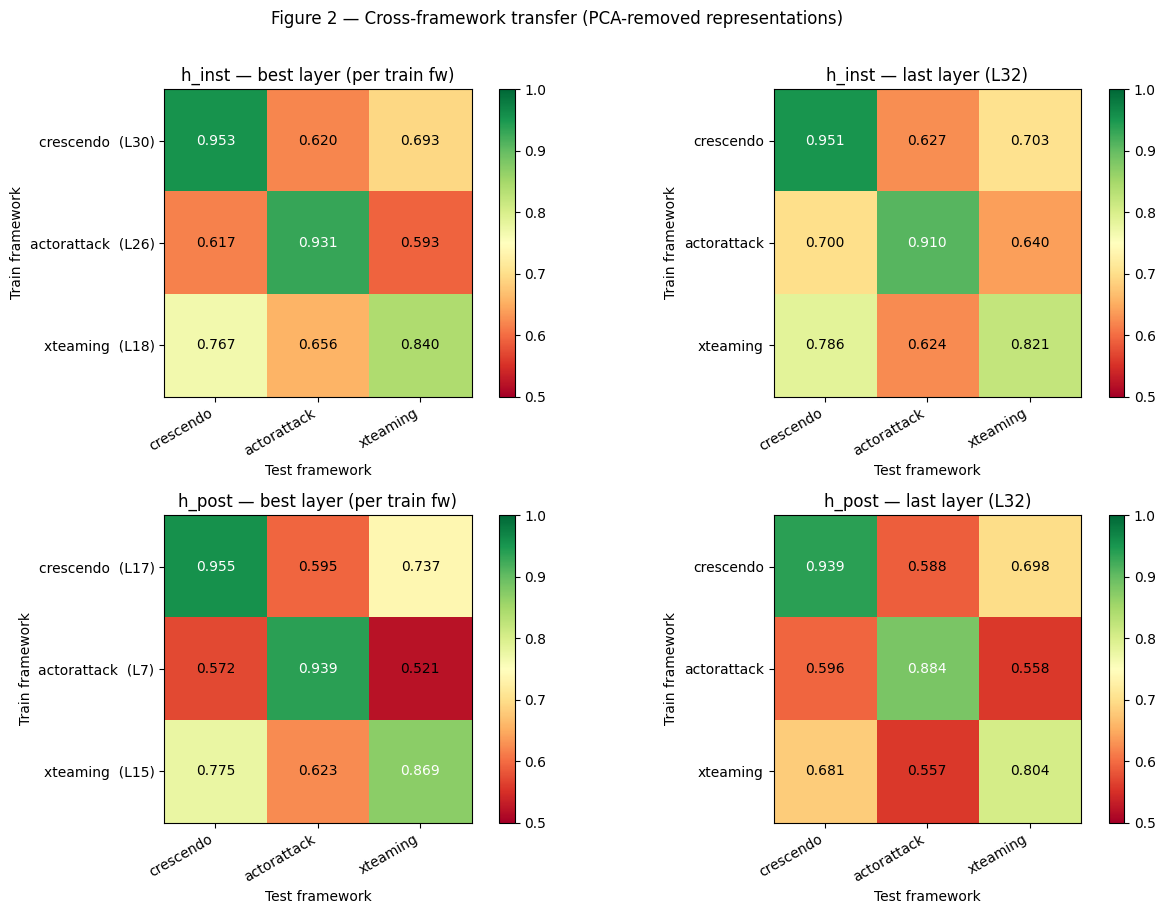

Saved figures/05_fig2_crossfw_transfer.png


In [9]:
LAST_LAYER = N_LAYERS - 1

transfer_pca = {}

for h_key in ["h_inst", "h_post"]:
    mat_best = np.zeros((3, 3))
    mat_last = np.zeros((3, 3))

    for i, train_fw in enumerate(FRAMEWORKS):
        probes = probe_results_pca[(train_fw, h_key)]["probes"]
        best_l = int(np.nanargmax(probe_results_pca[(train_fw, h_key)]["test_aucs"]))

        for j, test_fw in enumerate(FRAMEWORKS):
            X_te, y_te, _ = build_dataset_pca(test_fw, "test", h_key)
            mat_best[i, j] = roc_auc_score(y_te, probe_proba(X_te, probes, best_l))
            mat_last[i, j] = roc_auc_score(y_te, probe_proba(X_te, probes, LAST_LAYER))

    transfer_pca[(h_key, "best")] = mat_best
    transfer_pca[(h_key, "last")] = mat_last

best_layer_pca = {(fw, h_key): int(np.nanargmax(probe_results_pca[(fw, h_key)]["test_aucs"]))
                  for fw in FRAMEWORKS for h_key in ["h_inst", "h_post"]}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
configs = [
    (axes[0,0], "h_inst", "best",  "h_inst — best layer (per train fw)"),
    (axes[0,1], "h_inst", "last",  f"h_inst — last layer (L{N_LAYERS})"),
    (axes[1,0], "h_post", "best",  "h_post — best layer (per train fw)"),
    (axes[1,1], "h_post", "last",  f"h_post — last layer (L{N_LAYERS})"),
]
for ax, h_key, which, title in configs:
    mat = transfer_pca[(h_key, which)]
    im  = ax.imshow(mat, vmin=0.5, vmax=1.0, cmap="RdYlGn")
    if which == "best":
        ylabels = [f"{fw}  (L{best_layer_pca[(fw, h_key)]+1})" for fw in FRAMEWORKS]
    else:
        ylabels = FRAMEWORKS
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(FRAMEWORKS, rotation=30, ha="right")
    ax.set_yticklabels(ylabels)
    ax.set_xlabel("Test framework"); ax.set_ylabel("Train framework")
    ax.set_title(title)
    for ii in range(3):
        for jj in range(3):
            val = mat[ii, jj]
            ax.text(jj, ii, f"{val:.3f}", ha="center", va="center",
                    fontsize=10, color="black" if val < 0.85 else "white")
    plt.colorbar(im, ax=ax)

plt.suptitle("Figure 2 — Cross-framework transfer (PCA-removed representations)", y=1.01)
plt.tight_layout()
plt.savefig("../figures/05_fig2_crossfw_transfer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/05_fig2_crossfw_transfer.png")


## Figures 3 & 4 — K-sweep: P(harmful) over turns

Probe trained on final-turn representations, applied turn-by-turn.
**Solid = PCA-removed, dashed = raw** on the same axes.
The gap between the two at turn 1 is the topic contribution to P(harmful);
the rising slope is compliance priming — present in both conditions but
cleaner after topic removal.

3×3 grid: rows = training framework, columns = test framework.
★ diagonal = in-framework. Off-diagonal = cross-framework transfer.


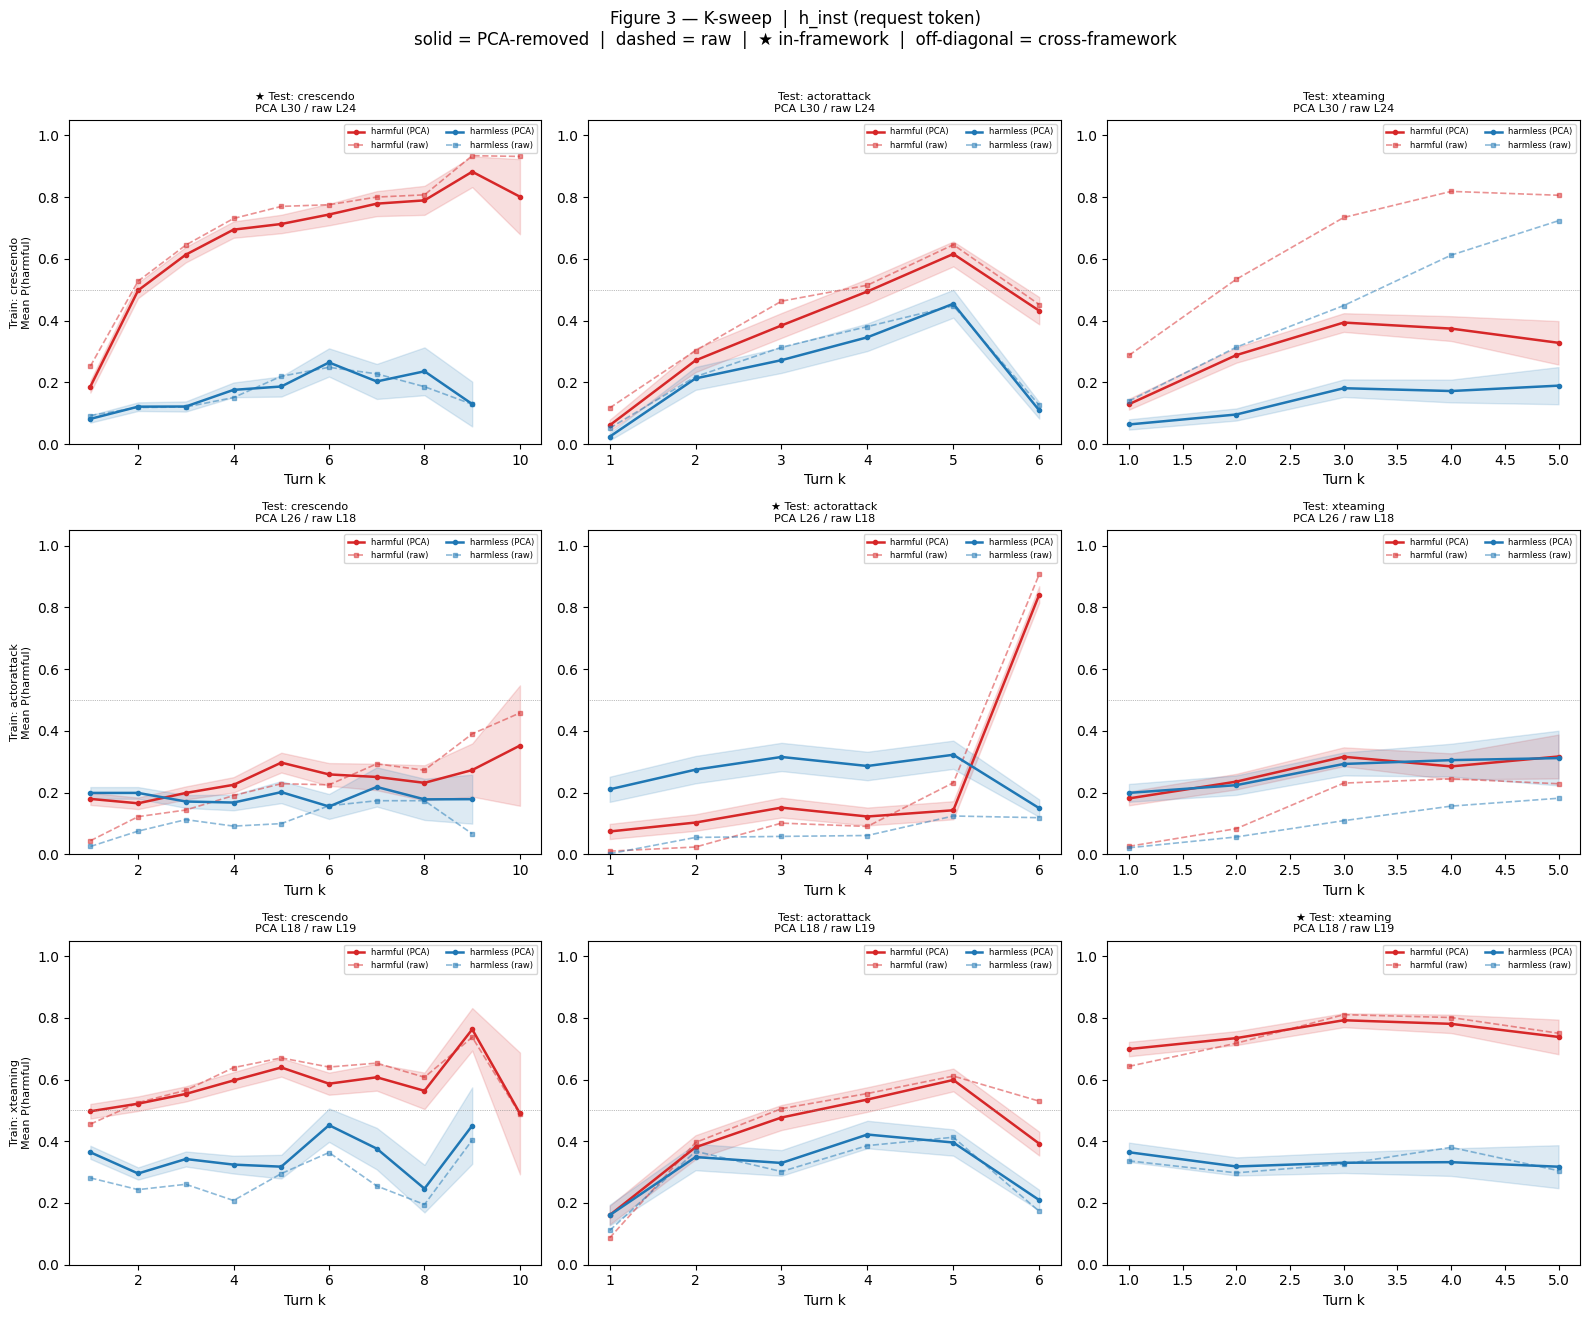

Saved ../figures/05_fig3_ksweep_hinst.png


In [10]:
def plot_ksweep_comparison(h_key, fig_path, fig_title):
    """3×3 k-sweep grid comparing PCA-removed (solid) vs raw (dashed)."""
    MIN_CONVS = 5
    fig, axes = plt.subplots(3, 3, figsize=(16, 13))

    for row, train_fw in enumerate(FRAMEWORKS):
        best_pca = int(np.nanargmax(probe_results_pca[(train_fw, h_key)]["test_aucs"]))
        best_raw = int(np.nanargmax(probe_results_raw[(train_fw, h_key)]["test_aucs"]))
        pr_pca   = probe_results_pca[(train_fw, h_key)]["probes"]
        pr_raw   = probe_results_raw[(train_fw, h_key)]["probes"]

        for col, test_fw in enumerate(FRAMEWORKS):
            ax = axes[row, col]

            for cat, goal_type, color, label in [
                ("accepted_harmful",  "harmful", "#d62728", "harmful"),
                ("accepted_harmless", "benign",  "#1f77b4", "harmless"),
            ]:
                meta   = traj[(test_fw, goal_type)]["meta"]
                h_arr  = traj[(test_fw, goal_type)][h_key]
                test_m = meta[meta["data_split"] == "test"]
                max_k  = int(test_m[test_m["category"] == cat]["turn_k"].max()) \
                         if (test_m["category"] == cat).any() else 0

                m_p, s_p, t_p = [], [], []
                m_r, s_r, t_r = [], [], []

                for k in range(1, max_k + 1):
                    rows_k = test_m[(test_m["category"] == cat) & (test_m["turn_k"] == k)]
                    if len(rows_k) < MIN_CONVS:
                        break
                    pos  = meta.index.get_indexer(rows_k.index)
                    X_k  = h_arr[pos].astype(np.float32)
                    pids = rows_k["pair_id"].values

                    p_pca = probe_proba(pca_h(X_k, pids, train_fw, h_key), pr_pca, best_pca)
                    p_raw = probe_proba(X_k, pr_raw, best_raw)

                    m_p.append(p_pca.mean()); s_p.append(p_pca.std()/np.sqrt(len(p_pca))); t_p.append(k)
                    m_r.append(p_raw.mean()); s_r.append(p_raw.std()/np.sqrt(len(p_raw))); t_r.append(k)

                if m_p:
                    m = np.array(m_p); s = np.array(s_p)
                    ax.plot(t_p, m, color=color, lw=1.8, marker="o", ms=3,
                            label=f"{label} (PCA)")
                    ax.fill_between(t_p, m-s, m+s, color=color, alpha=0.15)
                if m_r:
                    m = np.array(m_r); s = np.array(s_r)
                    ax.plot(t_r, m, color=color, lw=1.2, ls="--", marker="s",
                            ms=3, alpha=0.5, label=f"{label} (raw)")

            ax.axhline(0.5, color="gray", lw=0.5, ls=":")
            ax.set_ylim(0.0, 1.05)
            ax.set_xlabel("Turn k")
            diag = "★ " if train_fw == test_fw else ""
            ax.set_title(f"{diag}Test: {test_fw}\n"
                         f"PCA L{best_pca+1} / raw L{best_raw+1}", fontsize=8)
            ax.legend(fontsize=6, ncol=2)

        axes[row, 0].set_ylabel(f"Train: {train_fw}\nMean P(harmful)", fontsize=8)

    plt.suptitle(fig_title, y=1.01)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fig_path}")


plot_ksweep_comparison(
    h_key     = "h_inst",
    fig_path  = "../figures/05_fig3_ksweep_hinst.png",
    fig_title = (
        "Figure 3 — K-sweep  |  h_inst (request token)\n"
        "solid = PCA-removed  |  dashed = raw  |  "
        "★ in-framework  |  off-diagonal = cross-framework"
    ),
)


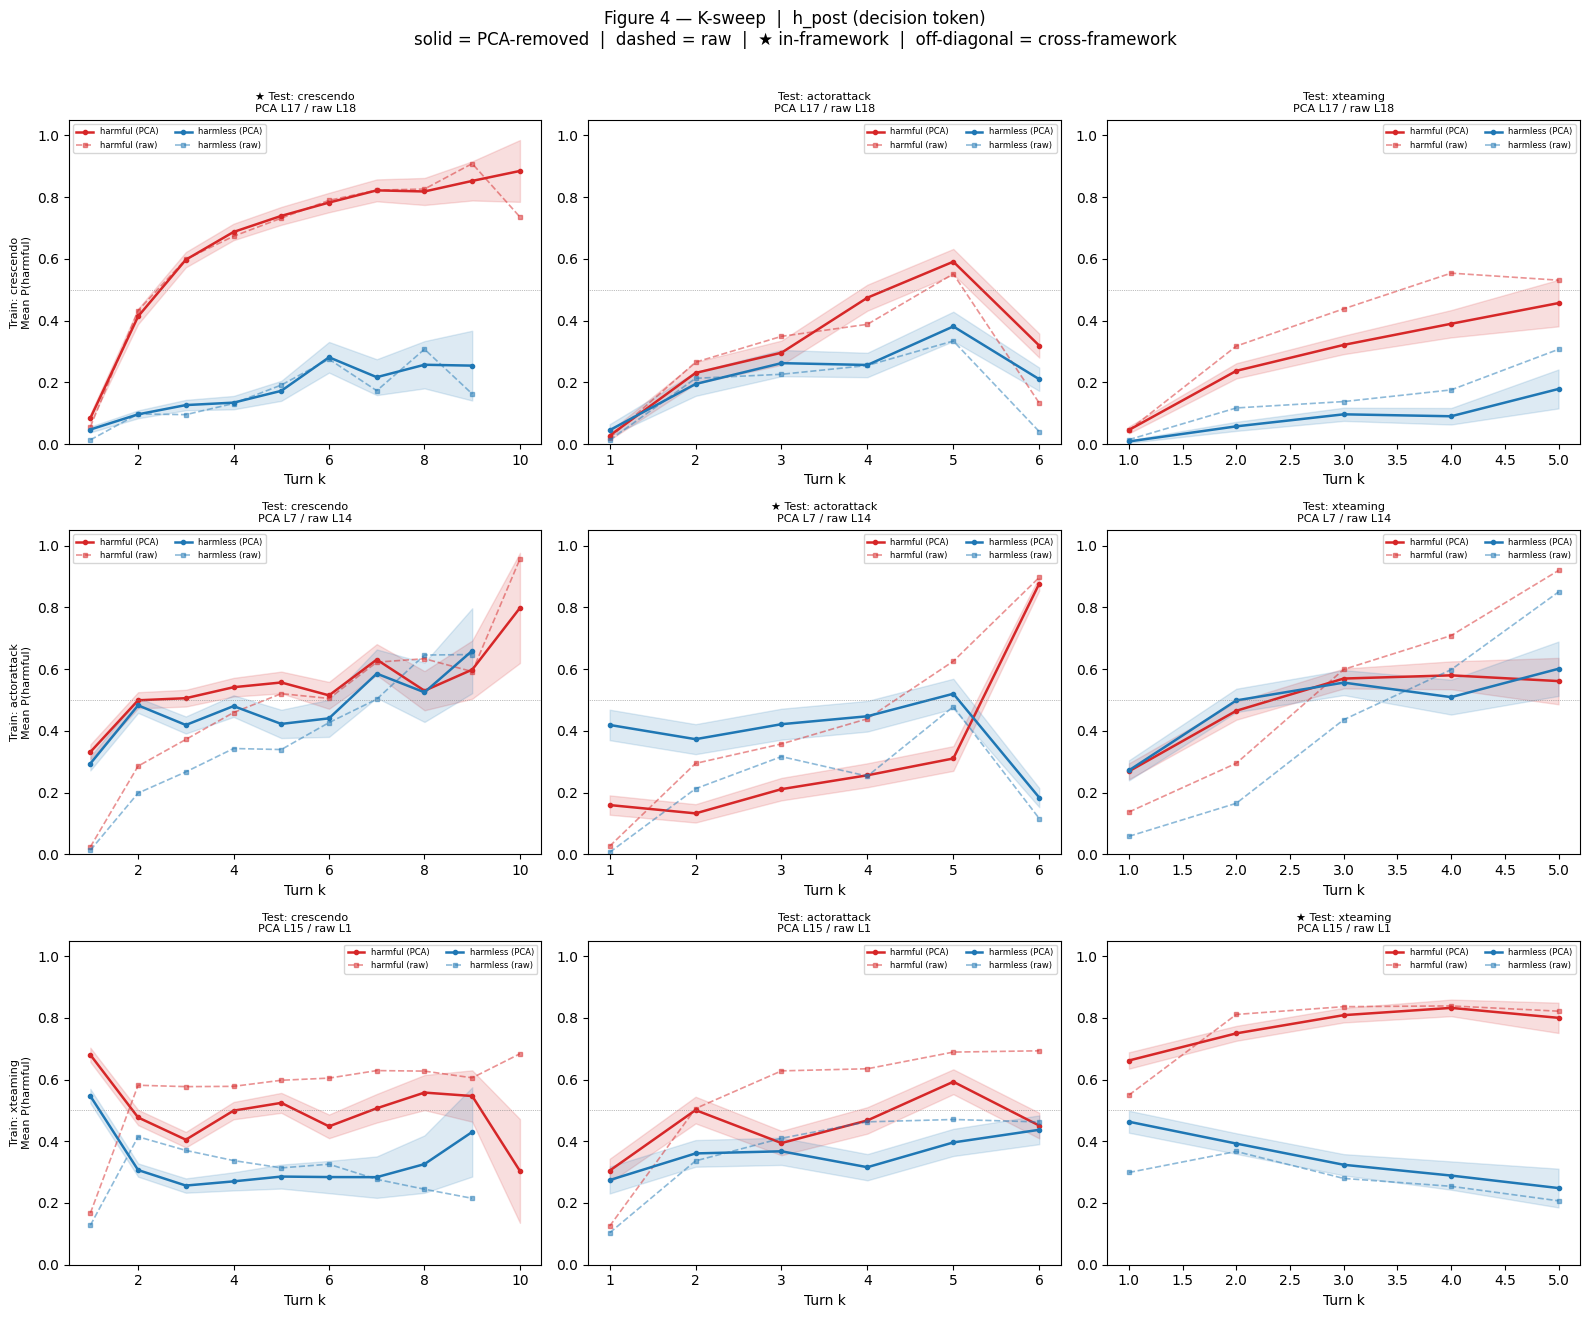

Saved ../figures/05_fig4_ksweep_hpost.png


In [11]:
plot_ksweep_comparison(
    h_key     = "h_post",
    fig_path  = "../figures/05_fig4_ksweep_hpost.png",
    fig_title = (
        "Figure 4 — K-sweep  |  h_post (decision token)\n"
        "solid = PCA-removed  |  dashed = raw  |  "
        "★ in-framework  |  off-diagonal = cross-framework"
    ),
)
